In [16]:
from gen_catalyst_design.db import Database, load_datadicts_from_db
import matplotlib.pyplot as plt
from ase.io import write, read
import numpy as np

In [17]:
use_log = True
train_samples = read("../../results/reconstruction_check/chgnet_result_all_fcc.traj", index=":")
rates = np.array([atoms.info["rate"] for atoms in train_samples])
if use_log:
    train_rates = np.log(rates)
else:
    train_rates = rates
train_eforms = np.array([atoms.info["e_form"] for atoms in train_samples])
train_struct_keys = ["".join(atoms.get_chemical_symbols()) for atoms in train_samples]

-25.4031805050845 5.967583005473827
3.297027587890625 11.807052612304688
-13.506331319773787 0.2994835290348434
4.69368 8.08461


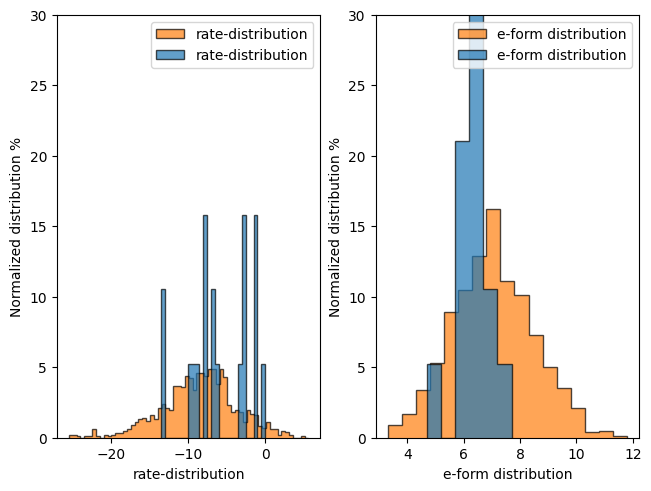

In [18]:
fig, axs = plt.subplots(1,2, layout="constrained")

rate_interval = 0.5
rate_max = np.max(train_rates)
rate_min = np.min(train_rates)


y_lims = 0.30*100
labels = [
    "rate-distribution",
    "e-form distribution"
]



for ax, dist, color, label in zip(axs, [train_rates, train_eforms], ["C1", "C1"], labels):
    min_val, max_val = np.min(dist), np.max(dist)
    print(min_val, max_val)
    bins = np.arange(min_val, max_val, rate_interval)
    hist, edges = np.histogram(dist, bins=bins)
    hist_norm = hist/np.sum(hist)
    ax.stairs(hist_norm*100, edges=edges, fill=True, alpha=0.7, edgecolor="k", linewidth=1, color=color, label=label)
    #ax.set_xlim([min_val, max_val])#np.ceil(rate_max)+step])
    ax.set_ylim([0.0, y_lims])
    ax.set_ylabel("Normalized distribution %")
    ax.set_xlabel(label)
    ax.legend()

i = 6
#i_conds_1 = e_form:10.0, rate=0.00035/log(rate)=-8.0
#i_conds_2 = e_form:20.0, rate=0.00035/log(rate)=-8.0
#i_conds_3 = e_form:10.0, rate=2.061e-9/log(rate)=-20.0
#i_conds_4 = e_form:20.0, rate=2.061e-9/log(rate)=-20.0
#i_conds_5 = e_form:40.0, rate=2.061e-9/log(rate)=-20.0

db_pred = Database.establish_connection(
    f"joint_evals_{i}.db",#f"e_form_{e_form_cond}_evals.db",#f"rate_{rate_cond}_evals.db",
    pth_header="rate_eform_testing/test_debug_cond/samples"
)

datadicts = load_datadicts_from_db(database=db_pred)



pred_rates = np.log(np.array([datadict["rate"] for datadict in datadicts]))
pred_eforms = np.array([datadict["e_form"] for datadict in datadicts])

for ax, dist, color, label in zip(axs, [pred_rates, pred_eforms], ["C0", "C0"], labels):
    min_val, max_val = np.min(dist), np.max(dist)
    print(min_val, max_val)
    bins = np.arange(min_val, max_val, rate_interval)
    hist, edges = np.histogram(dist, bins=bins)
    hist_norm = hist/np.sum(hist)
    ax.stairs(hist_norm*100, edges=edges, fill=True, alpha=0.7, edgecolor="k", linewidth=1, color=color, label=label)
    #ax.set_xlim([min_val, max_val])#np.ceil(rate_max)+step])
    ax.set_ylim([0.0, y_lims])
    ax.set_ylabel("Normalized distribution %")
    ax.set_xlabel(label)
    ax.legend()




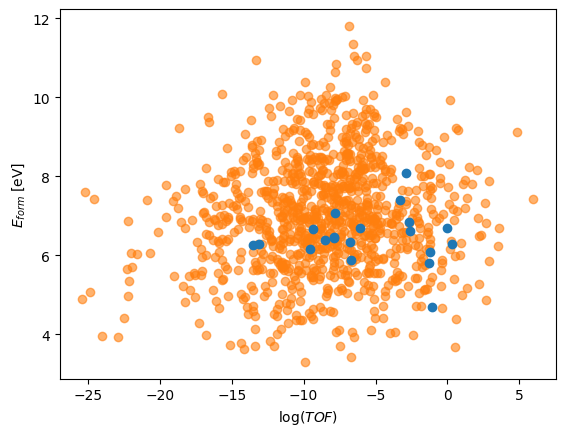

In [19]:
fig, ax = plt.subplots()
ax.set_ylabel(r"$E_{form}$ [eV]")
ax.set_xlabel(r"$\log(TOF)$")
ax.scatter(train_rates, train_eforms, c="C1", alpha=0.6)
ax.scatter(pred_rates, pred_eforms, c="C0")


In [10]:
i=0
for datadict in datadicts:
    elements = datadict["elements"]
    query = "".join(elements)
    if query not in train_struct_keys:
        i+=1

In [15]:
np.exp(0)

np.float64(1.0)